**Problem Statement:**

Build a sentiment analysis model using Recurrent Neural Networks (RNNs) to
classify movie reviews from the IMDB dataset into positive or negative
sentiments.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

**Dataset:**

The dataset comprises 25,000 movie reviews from IMDB, labeled by sentiment
(positive/negative). Reviews have been preprocessed, and each review is
encoded as a sequence of word indices (integers). The words in the dataset are
indexed by overall frequency in the dataset, allowing for quick filtering operations
such as: "only consider the top 10,000 most common words, but eliminate the top
20 most common words".

Data Preprocessing:

● Load the IMDB dataset, keeping only the top 10,000 most frequently occurring words.

● Pad the sequences so that they all have the same length.

In [11]:
#load dataset
vocabulary_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocabulary_size)
print(x_train, y_train)
print(x_test, y_test)

[list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32])
 list([1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 

In [12]:
#RNN require fixed length sequence
maxlen = 200
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)
print(x_train.shape, x_test.shape)

(25000, 200) (25000, 200)


Model Building:


● Create a Sequential RNN model using TensorFlow and Keras.

● The model should consist of an Embedding layer, a SimpleRNN layer, and a Dense output layer.

● Compile the model, specifying the appropriate optimizer, loss function, and metrics.




In [13]:
#Build RNN model
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Embedding(input_dim=vocabulary_size,
                                    output_dim=32, input_length=maxlen))
model.add(tf.keras.layers.SimpleRNN(32))

model.add(tf.keras.layers.Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
#Train model
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9348 - loss: 0.1833 - val_accuracy: 0.8476 - val_loss: 0.3785
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9554 - loss: 0.1317 - val_accuracy: 0.8516 - val_loss: 0.4221
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9784 - loss: 0.0743 - val_accuracy: 0.8298 - val_loss: 0.4684


In [20]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.9348499774932861, 0.9553999900817871, 0.9783999919891357]
[0.847599983215332, 0.8515999913215637, 0.829800009727478]


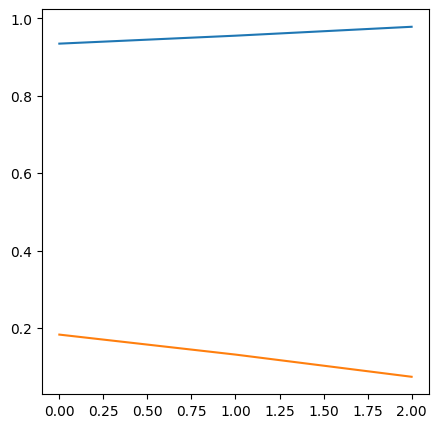

In [23]:
#plot epochs loss and accuracy
plt.figure(figsize=(5,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.show()

In [24]:
#evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(test_loss, test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8243 - loss: 0.4870
0.4870438277721405 0.8243200182914734


In [28]:
x_train.shape

(25000, 200)

In [32]:
#predict a data
res = model.predict(x_train[:128])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [45]:
pd.Series(res.reshape(-1).round()).value_counts()

,count
0.0,72
1.0,56
